# (08) New Implementation: working?

host: ```mach```, device: ```cuda:2```

**motivation:** <br>
The new implementation works?

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 2
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:2  ———  host: mach

## 128 = 1 § 128 . . .  beta = 1.0

- t_train = 128
- t_tbptt = 1
- beta = 1.0

In [3]:
model_type = 'poisson'
cfg_mod, cfg_tr = default_configs(model_type, 'vH16')

cfg_mod['t_train'] = 128
cfg_mod['t_tbptt'] = 1
cfg_mod['beta_outer'] = 1.0

# cfg_tr['batch_size'] = 200
cfg_tr['epochs'] = 30
cfg_tr['lr'] = 1e-4

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](
        CFG_CLASSES[model_type](**cfg_mod)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)
tr.n_iters

15450

In [5]:
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}")

poisson_vH16_t-128[§1]_b-1_k-[512]_u-10,du-10
b200-ep30-lr(0.0001)_temp(0.01:0.5)_gr(500)

In [6]:
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,
        10, 10], device='cuda:2', dtype=torch.int32)

In [7]:
tr.train()

epoch # 30, avg loss: 325.142: 100%|█████████| 30/30 [8:08:34<00:00, 977.15s/it]


In [8]:
print(tr.model.layer.n_exp)

tensor([25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25,
        25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25,
        25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 24, 24,
        24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24,
        24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24,
        24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24,
        24, 24, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
        23, 23], device='cuda:2', dtype=torch.int32)

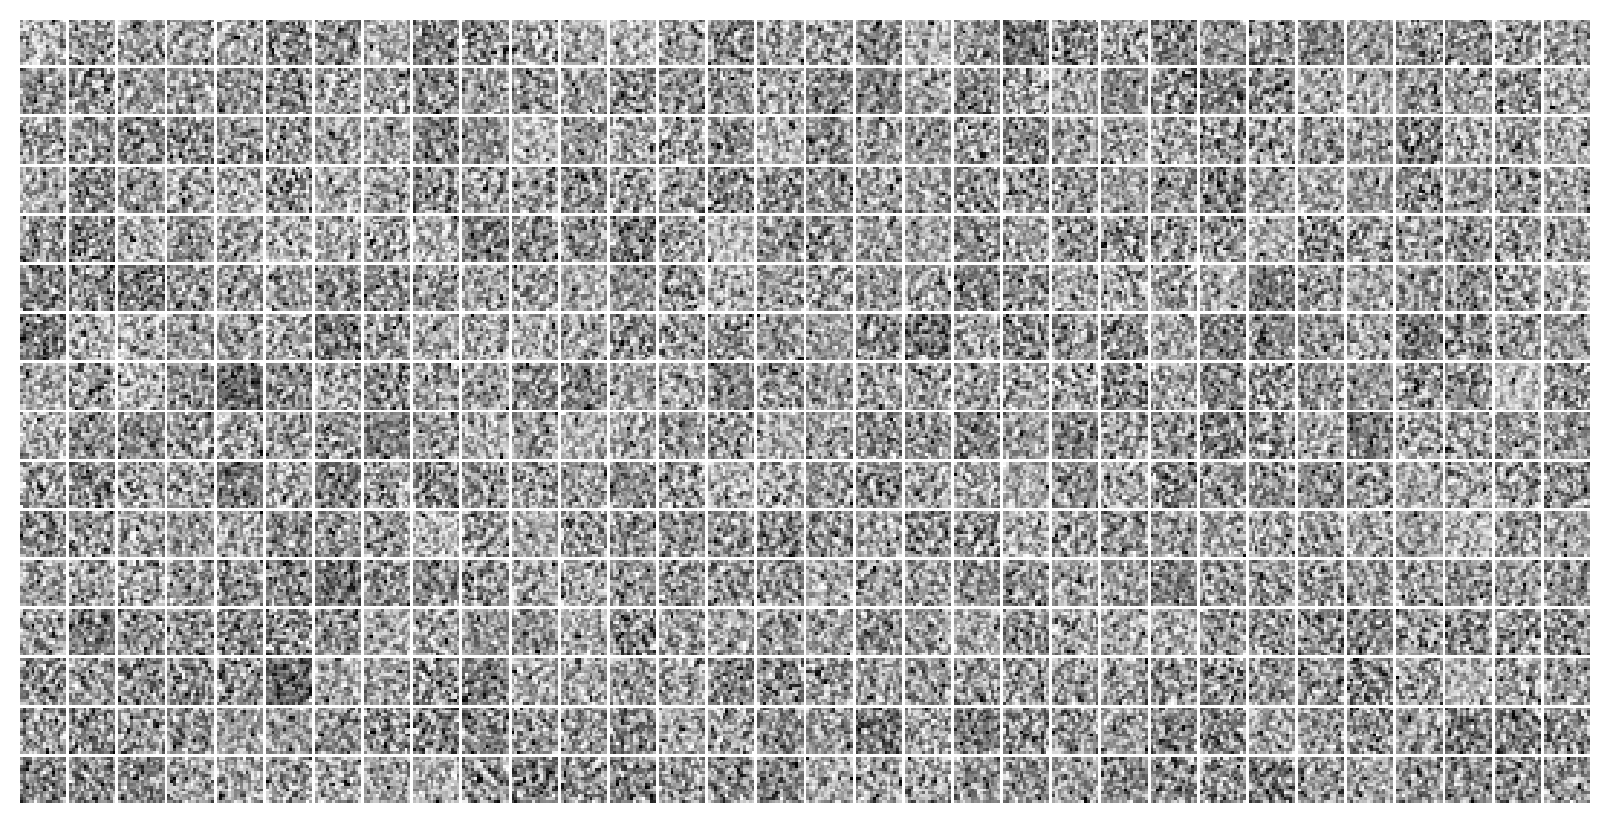

In [9]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

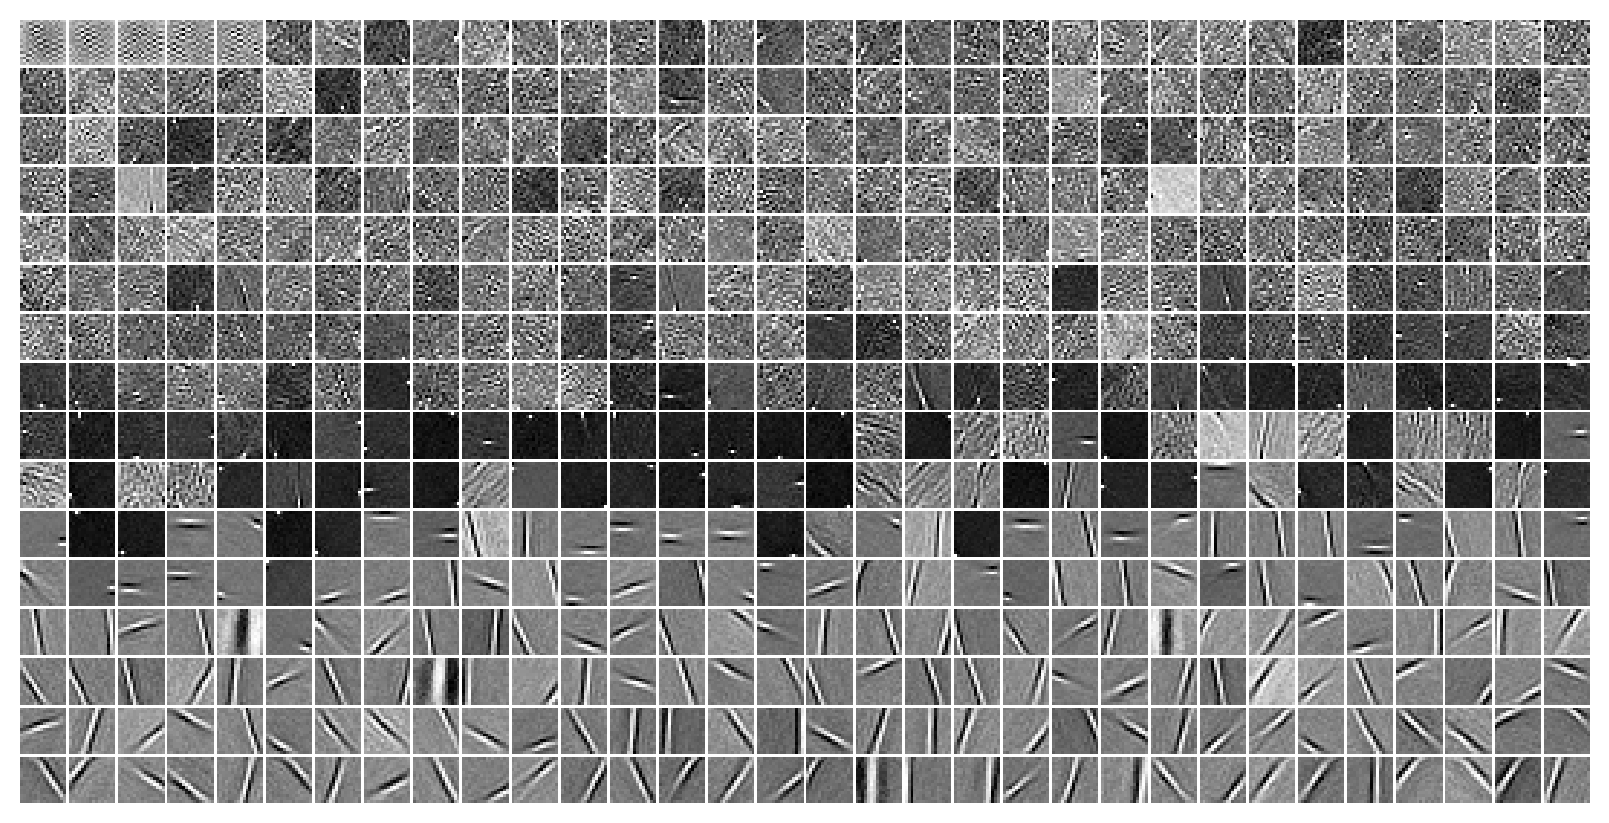

In [9]:
### Was: 16

In [10]:
feeder = tr.get_feeder()
r2, pz, du_norm = [], [], []

for t in tqdm(range(20000)):
    tr.model.update_time(t)
    output = tr.model.xtract_ftr(
        feeder[t],
        return_extras=['du', 'r2', 'samples'],
    )
    _nrm = torch.linalg.norm(output['du'], dim=1).mean().item()
    _pz = tonp(output['samples'] == 0).mean()
    _r2 = output['r2'].mean().item()
    du_norm.append(_nrm)
    pz.append(_pz)
    r2.append(_r2)

data2plot = {'r2': r2, '%-zeros': pz, 'du_norm': du_norm}
data2plot = {k: np.asarray(v) for k, v in data2plot.items()}

100%|████████████████████████████████████| 20000/20000 [00:53<00:00, 375.47it/s]


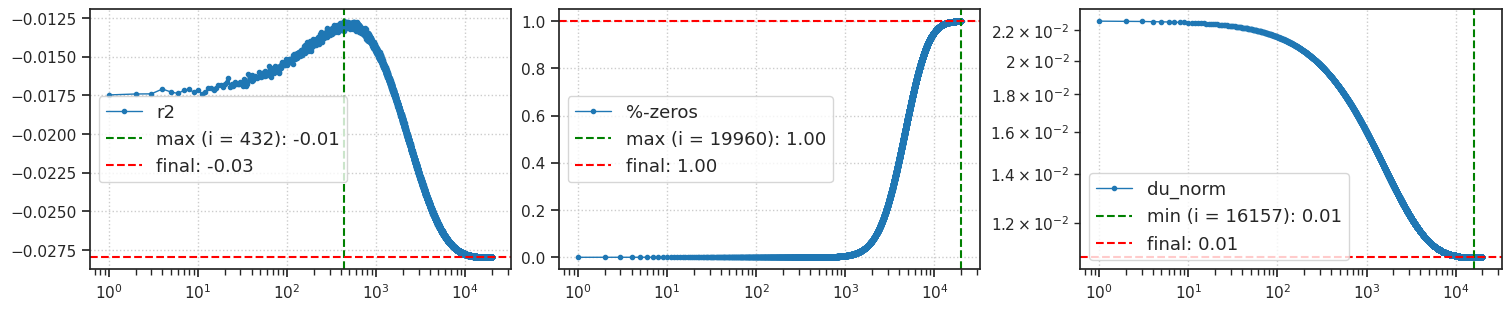

In [11]:
fig = plot_convergence(data2plot, items=data2plot, nrows=1)
plt.show()

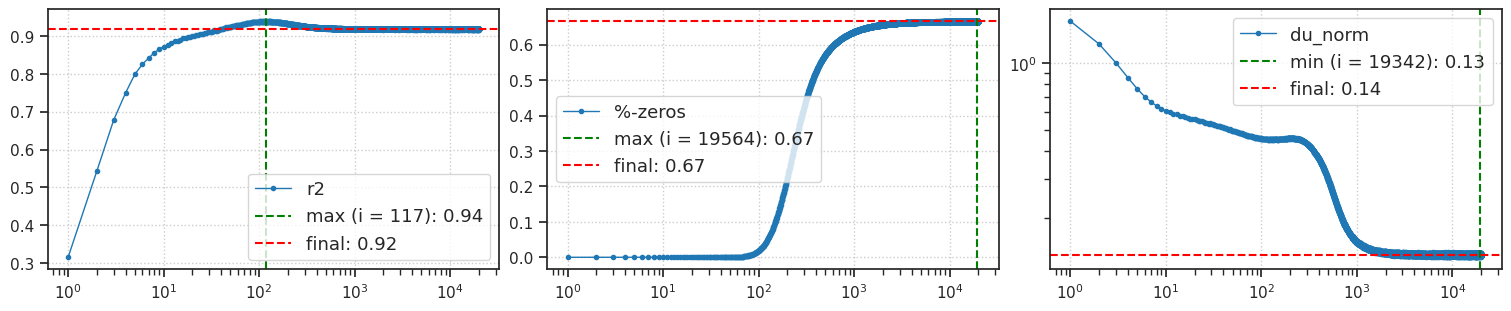

In [11]:
### Was: 16

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs(model_type, 'vH16')

cfg_vae['t_train'] = 16
cfg_vae['beta_outer'] = 16.0
# cfg_tr['batch_size'] = 200
cfg_tr['epochs'] = 100

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](
        CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)
tr.n_iters

51500

In [5]:
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}")

poisson_vH16_t-16_b-16_k-[512]_u-10,du-10
b200-ep100-lr(0.005)_temp(0.01:0.5)_gr(500)

In [6]:
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [7]:
tr.train()

epoch # 100, avg loss: 262.064: 100%|█████████| 100/100 [48:06<00:00, 28.86s/it]


In [8]:
print(tr.model.layer.n_exp)

tensor([25, 35, 47, 61, 73, 81, 86, 88, 89, 89, 89, 89, 89, 89, 89, 89],
       device='cuda:1', dtype=torch.int32)

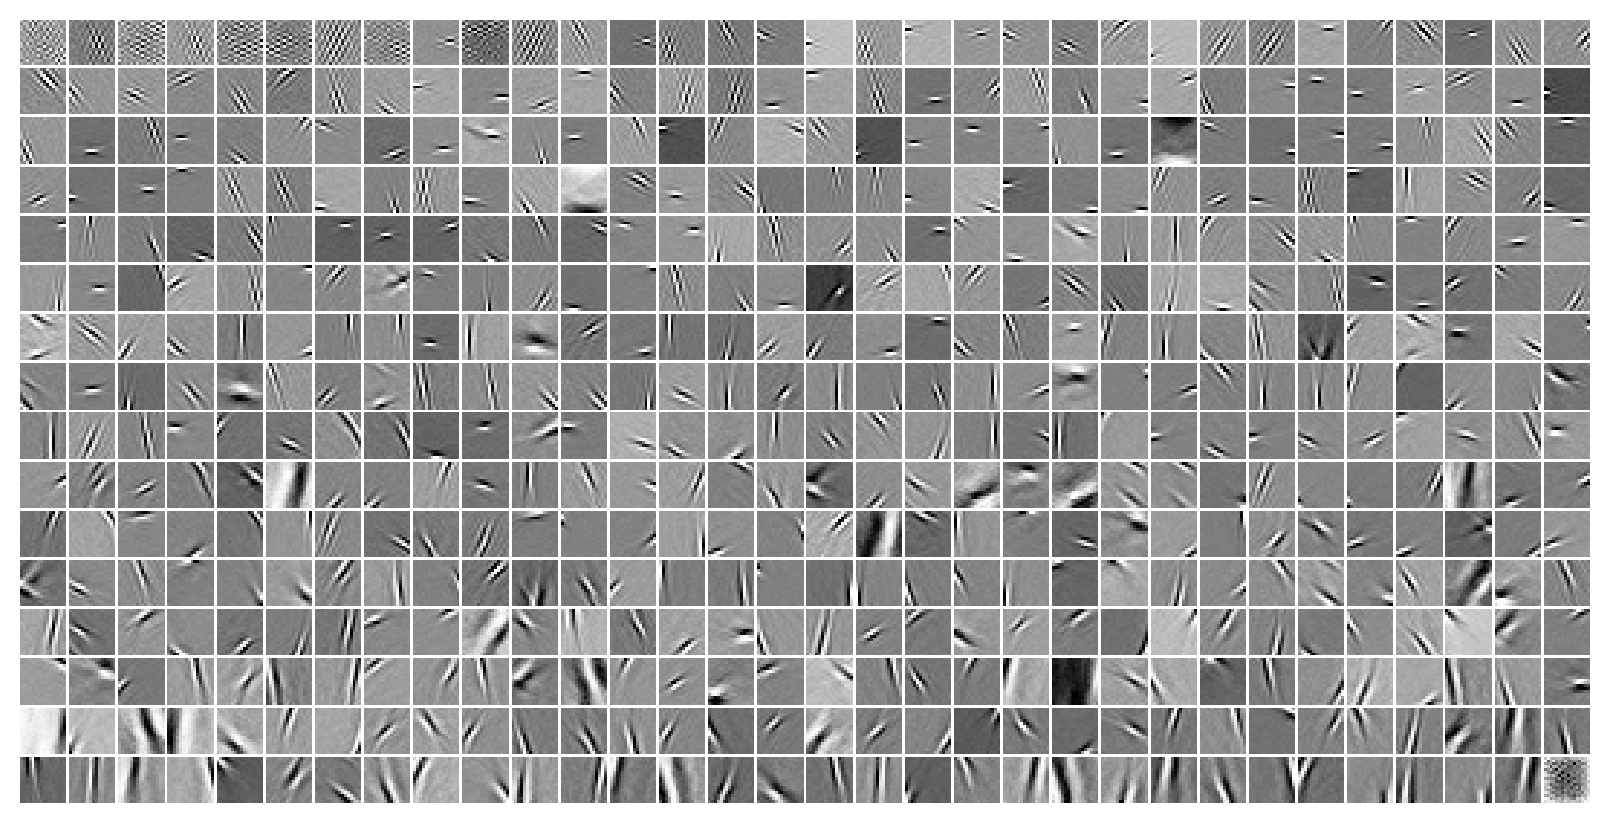

In [9]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));